In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_2023 = pd.read_csv("../data/Delayed_Cancelled_Flights_2023sample.csv")

print("2023 sample dataset size:", df_2023.shape)
df_2023.head()

2023 sample dataset size: (10000, 17)


,FL_DATE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAYED
0,3/25/2023 12:00:00 AM,3,6,AA,1961,SAT,DFW,60.0,67.0,0.0,NaN,0.0,7.0,7.0,0.0,53.0,True
1,6/5/2023 12:00:00 AM,6,1,AA,2762,GSO,CLT,43.0,29.0,0.0,NaN,0.0,0.0,29.0,0.0,0.0,True
2,8/10/2023 12:00:00 AM,8,4,G4,3230,PVU,SNA,-1.0,41.0,0.0,NaN,0.0,0.0,41.0,0.0,0.0,True
3,7/4/2023 12:00:00 AM,7,2,NK,2078,MCO,BWI,27.0,31.0,0.0,NaN,27.0,4.0,0.0,0.0,0.0,True
4,8/9/2023 12:00:00 AM,8,3,MQ,3447,ORD,CMH,94.0,110.0,0.0,NaN,33.0,16.0,0.0,0.0,61.0,True


In [4]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FL_DATE              10000 non-null  object 
 1   MONTH                10000 non-null  int64  
 2   DAY_OF_WEEK          10000 non-null  int64  
 3   OP_UNIQUE_CARRIER    10000 non-null  object 
 4   OP_CARRIER_FL_NUM    10000 non-null  int64  
 5   ORIGIN               10000 non-null  object 
 6   DEST                 10000 non-null  object 
 7   DEP_DELAY            9441 non-null   float64
 8   ARR_DELAY            9421 non-null   float64
 9   CANCELLED            10000 non-null  float64
 10  CANCELLATION_CODE    579 non-null    object 
 11  WEATHER_DELAY        9421 non-null   float64
 12  NAS_DELAY            9421 non-null   float64
 13  CARRIER_DELAY        9421 non-null   float64
 14  SECURITY_DELAY       9421 non-null   float64
 15  LATE_AIRCRAFT_DELAY  9421 non-null   

In [5]:
df_2023.describe()

,MONTH,DAY_OF_WEEK,OP_CARRIER_FL_NUM,DEP_DELAY,ARR_DELAY,CANCELLED,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,10000.000000,10000.000000,10000.00000,9441.000000,9421.000000,10000.000000,9421.000000,9421.000000,9421.000000,9421.000000,9421.000000
mean,6.213700,4.096900,2166.76210,66.835293,70.671585,0.057900,3.519690,12.774228,26.433287,0.100308,27.844072
std,3.198196,1.989549,1515.73614,112.660675,110.032398,0.233566,29.400232,30.223093,84.689207,1.735241,67.263378
min,1.000000,1.000000,1.00000,-17.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,962.00000,19.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,4.000000,1900.00000,40.000000,40.000000,0.000000,0.000000,0.000000,4.000000,0.000000,2.000000
75%,9.000000,6.000000,2978.25000,77.000000,78.000000,0.000000,0.000000,16.000000,22.000000,0.000000,33.000000
max,12.000000,7.000000,6871.00000,2508.000000,2511.000000,1.000000,1164.000000,1075.000000,2508.000000,81.000000,1695.000000


In [6]:
print("Missing values per column:")
print(df_2023.isnull().sum())

Missing values per column:
FL_DATE                   0
MONTH                     0
DAY_OF_WEEK               0
OP_UNIQUE_CARRIER         0
OP_CARRIER_FL_NUM         0
ORIGIN                    0
DEST                      0
DEP_DELAY               559
ARR_DELAY               579
CANCELLED                 0
CANCELLATION_CODE      9421
WEATHER_DELAY           579
NAS_DELAY               579
CARRIER_DELAY           579
SECURITY_DELAY          579
LATE_AIRCRAFT_DELAY     579
DELAYED                   0
dtype: int64


In [7]:
print("2023 Delayed vs Not Delayed Counts:")
print(df_2023["DELAYED"].value_counts())

2023 Delayed vs Not Delayed Counts:
DELAYED
True     9421
False     579
Name: count, dtype: int64


In [8]:
delay_cols = [
    "LATE_AIRCRAFT_DELAY",
    "CARRIER_DELAY",
    "NAS_DELAY",
    "WEATHER_DELAY",
    "SECURITY_DELAY"
]

print("2023 Average Delay Minutes by Cause:")
print(df_2023[delay_cols].mean())

2023 Average Delay Minutes by Cause:
LATE_AIRCRAFT_DELAY    27.844072
CARRIER_DELAY          26.433287
NAS_DELAY              12.774228
WEATHER_DELAY           3.519690
SECURITY_DELAY          0.100308
dtype: float64


In [9]:
df_2024 = pd.read_csv("../data/Delayed_Cancelled_Flights_sample.csv")

print("2024 sample dataset size:", df_2024.shape)

2024 sample dataset size: (10000, 17)


In [10]:
print("2023 Delayed counts:")
print(df_2023["DELAYED"].value_counts())

print("\n2024 Delayed counts:")
print(df_2024["DELAYED"].value_counts())

2023 Delayed counts:
DELAYED
True     9421
False     579
Name: count, dtype: int64

2024 Delayed counts:
DELAYED
True     9325
False     675
Name: count, dtype: int64


In [11]:
delay_cols = [
    "LATE_AIRCRAFT_DELAY",
    "CARRIER_DELAY",
    "NAS_DELAY",
    "WEATHER_DELAY",
    "SECURITY_DELAY"
]

comparison = pd.DataFrame({
    "2023": df_2023[delay_cols].mean(),
    "2024": df_2024[delay_cols].mean()
})

print(comparison)

                          2023       2024
LATE_AIRCRAFT_DELAY  27.844072  28.082145
CARRIER_DELAY        26.433287  24.538338
NAS_DELAY            12.774228  13.096086
WEATHER_DELAY         3.519690   4.057265
SECURITY_DELAY        0.100308   0.125469


Sample dataset size: (10000, 17)

Delayed vs Cancelled Counts:
DELAYED
True     9421
False     579
Name: count, dtype: int64

Average Delay Minutes by Cause:
LATE_AIRCRAFT_DELAY    27.844072
CARRIER_DELAY          26.433287
NAS_DELAY              12.774228
WEATHER_DELAY           3.519690
SECURITY_DELAY          0.100308
dtype: float64


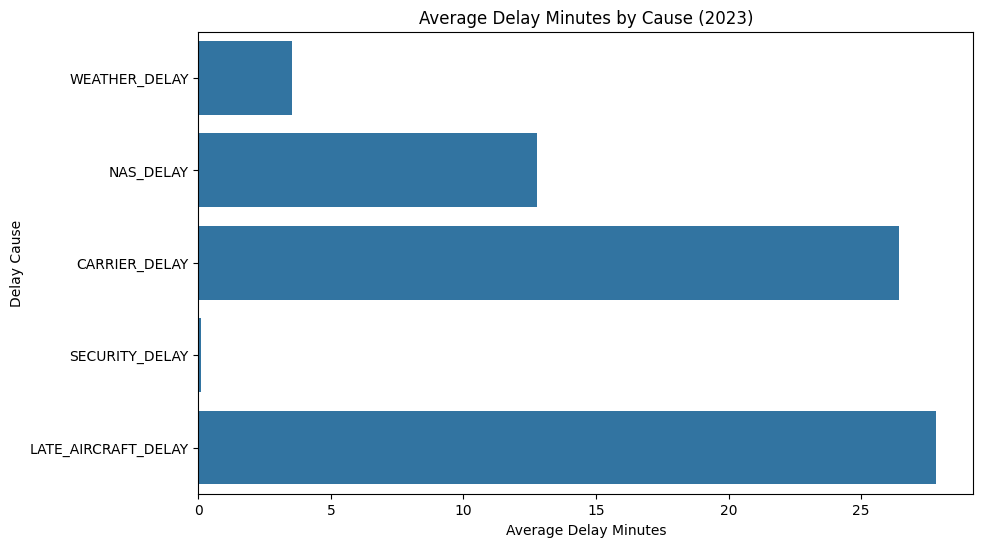


Top 10 Departure Airports with Disruptions:
ORIGIN
DEN    492
ATL    459
DFW    458
ORD    421
LAS    368
MCO    322
CLT    307
LAX    279
LGA    243
BOS    231
dtype: int64


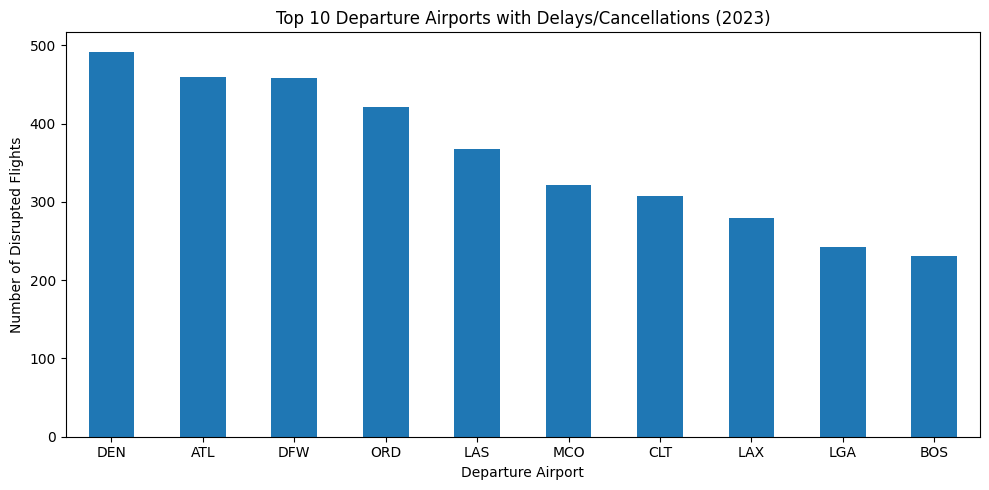

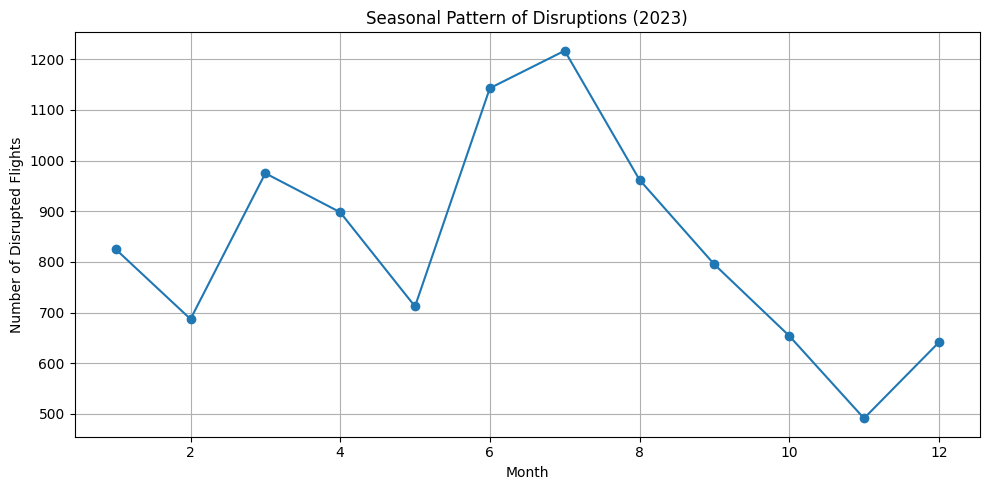

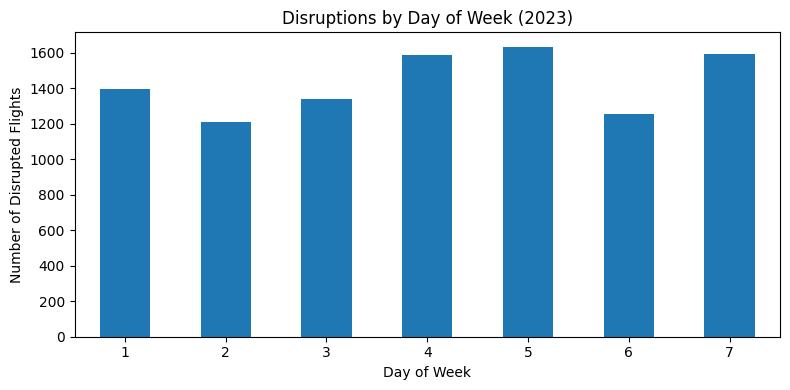

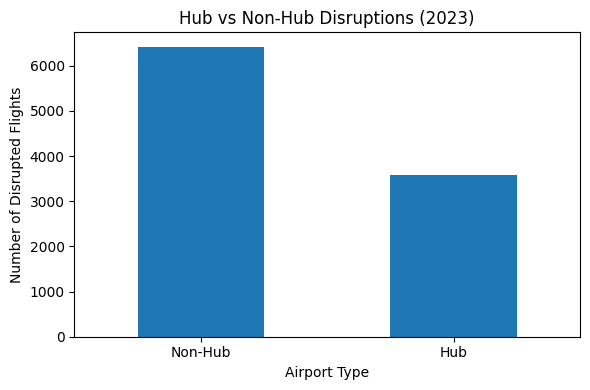


Average Delay Minutes by Hub Status:
            DEP_DELAY  ARR_DELAY
HUB STATUS                      
Hub         64.508947  68.287015
Non-Hub     68.150033  72.020608


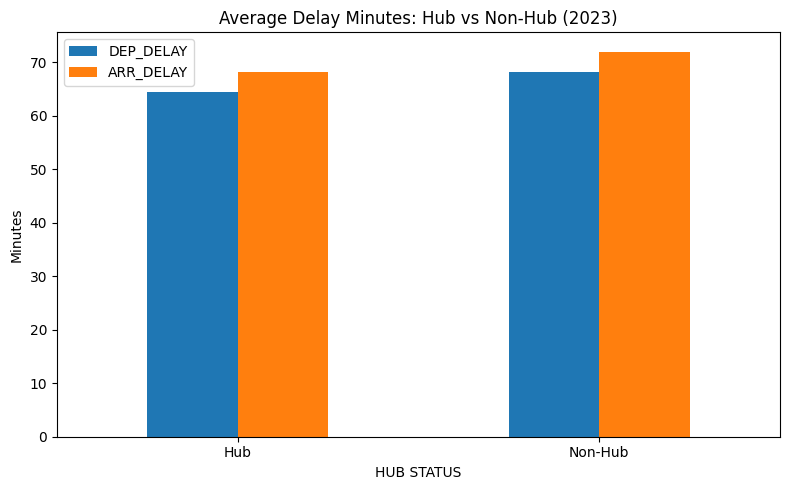

In [22]:
print("Sample dataset size:", df_2023.shape)

print("\nDelayed vs Cancelled Counts:")
print(df_2023["DELAYED"].value_counts())

delay_causes = [
    "WEATHER_DELAY",
    "NAS_DELAY",
    "CARRIER_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

print("\nAverage Delay Minutes by Cause:")
print(df_2023[delay_causes].mean().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=df_2023[delay_causes].mean().values, y=delay_causes)
plt.title("Average Delay Minutes by Cause (2023)")
plt.xlabel("Average Delay Minutes")
plt.ylabel("Delay Cause")
plt.show()

top_airports_2023 = (
    df_2023.groupby("ORIGIN")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Departure Airports with Disruptions:")
print(top_airports_2023)

top_airports_2023.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Departure Airports with Delays/Cancellations (2023)")
plt.xlabel("Departure Airport")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

monthly_disruptions_2023 = df_2023.groupby("MONTH").size().sort_index()

monthly_disruptions_2023.plot(marker="o", figsize=(10,5))
plt.title("Seasonal Pattern of Disruptions (2023)")
plt.xlabel("Month")
plt.ylabel("Number of Disrupted Flights")
plt.grid(True)
plt.tight_layout()
plt.show()

dow_disruptions_2023 = df_2023.groupby("DAY_OF_WEEK").size().sort_index()

dow_disruptions_2023.plot(kind="bar", figsize=(8,4))
plt.title("Disruptions by Day of Week (2023)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

hub_airports_2023 = top_airports_2023.index.tolist()

df_2023["HUB STATUS"] = df_2023["ORIGIN"].apply(lambda x: "Hub" if x in hub_airports_2023 else "Non-Hub")

hub_counts_2023 = df_2023["HUB STATUS"].value_counts()

hub_counts_2023.plot(kind="bar", figsize=(6,4))
plt.title("Hub vs Non-Hub Disruptions (2023)")
plt.xlabel("Airport Type")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

hub_delay_stats_2023 = df_2023.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]].mean()

print("\nAverage Delay Minutes by Hub Status:")
print(hub_delay_stats_2023)

hub_delay_stats_2023.plot(kind="bar", figsize=(8,5))
plt.title("Average Delay Minutes: Hub vs Non-Hub (2023)")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

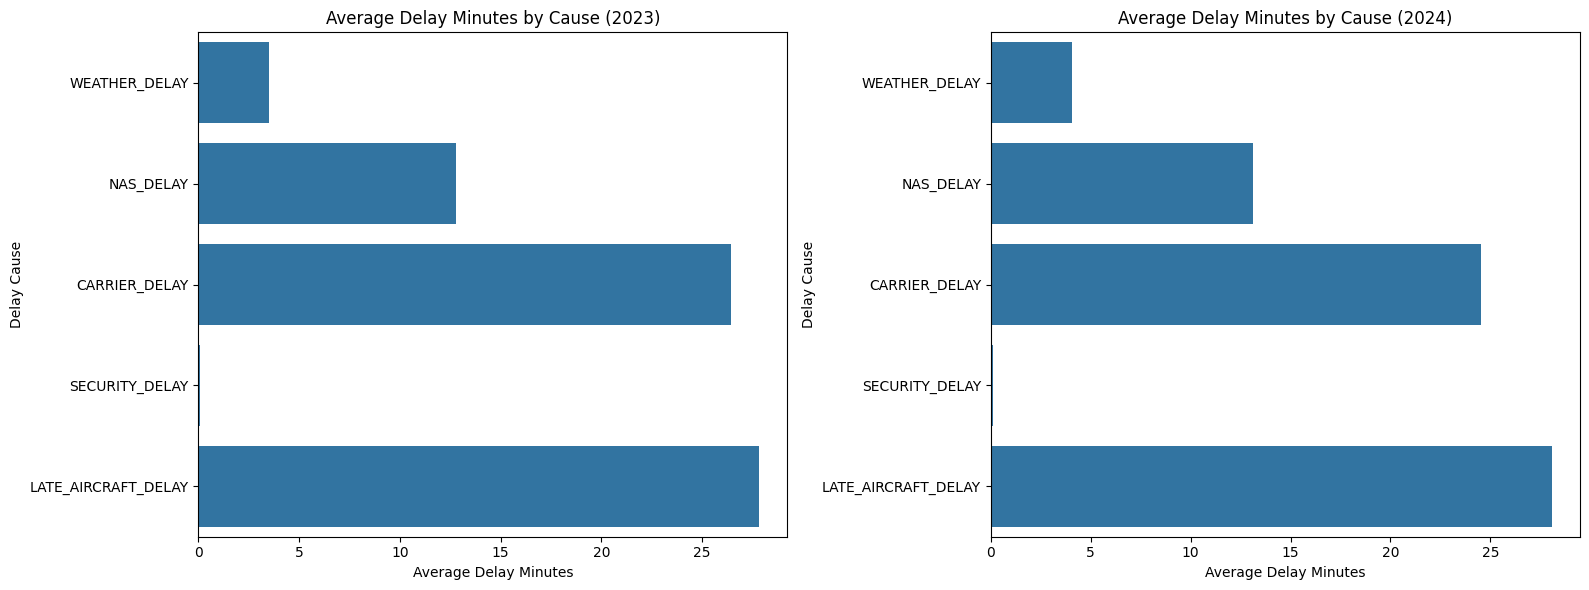

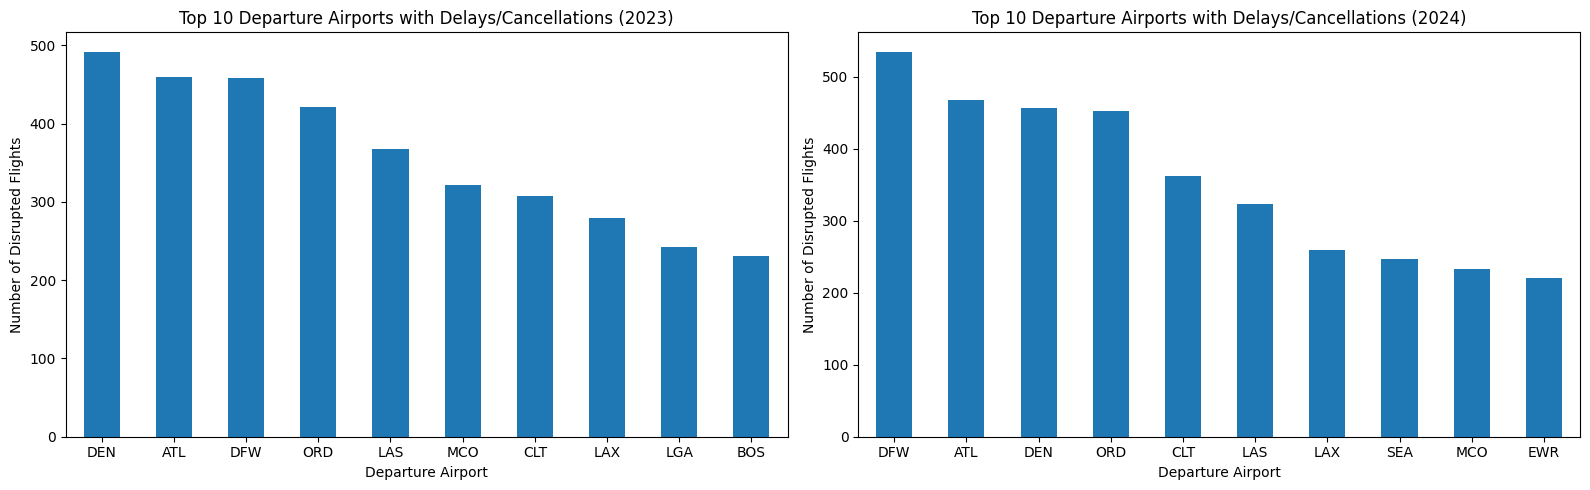

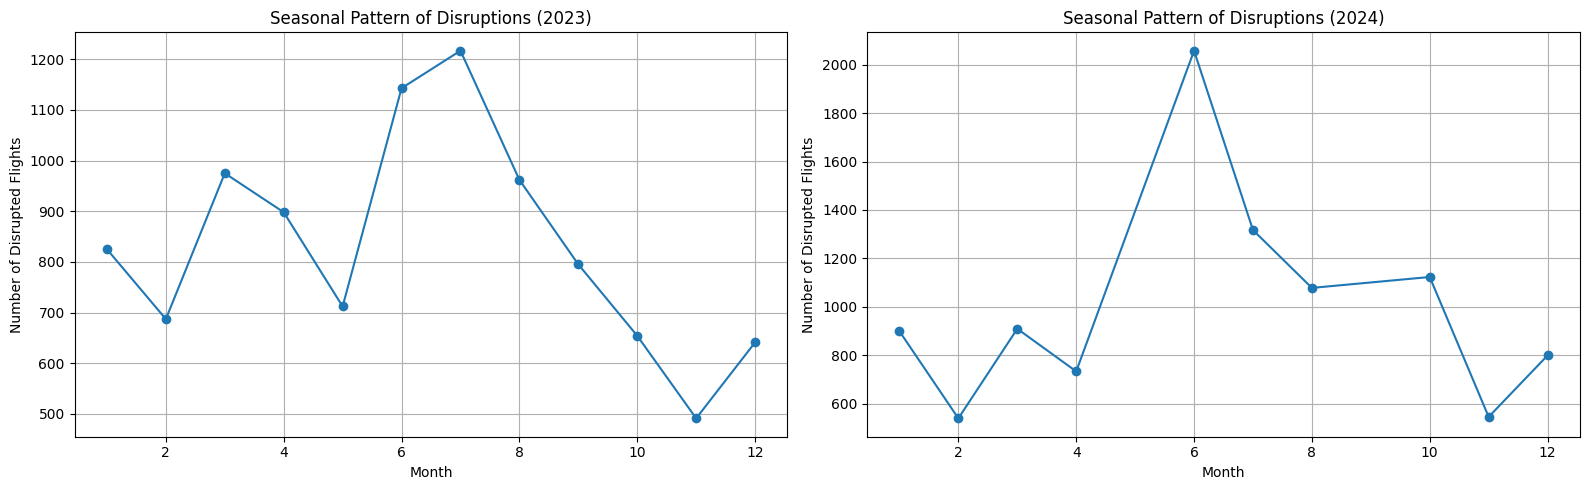

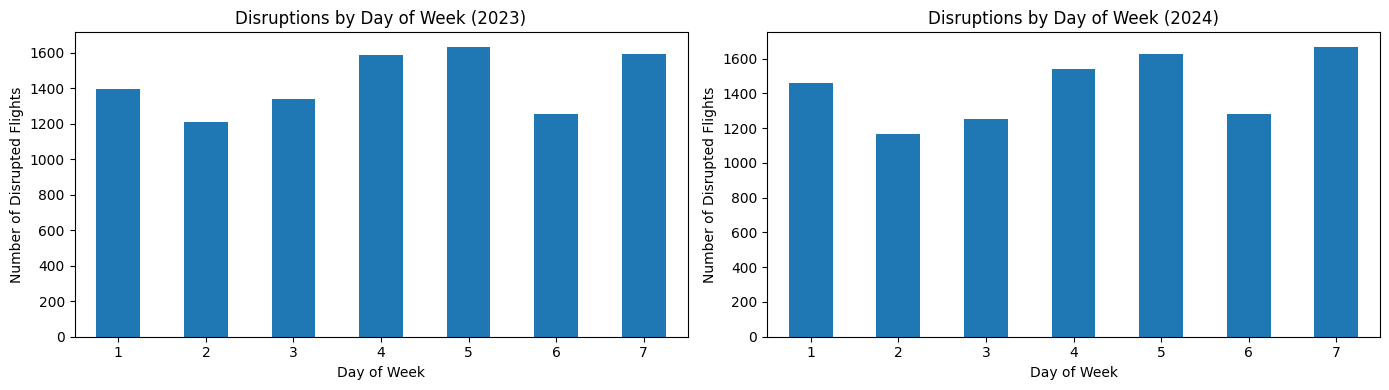

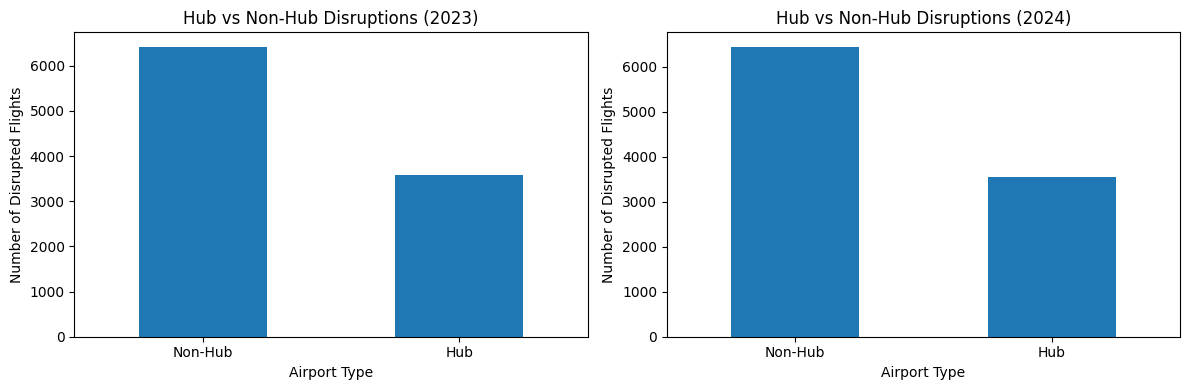

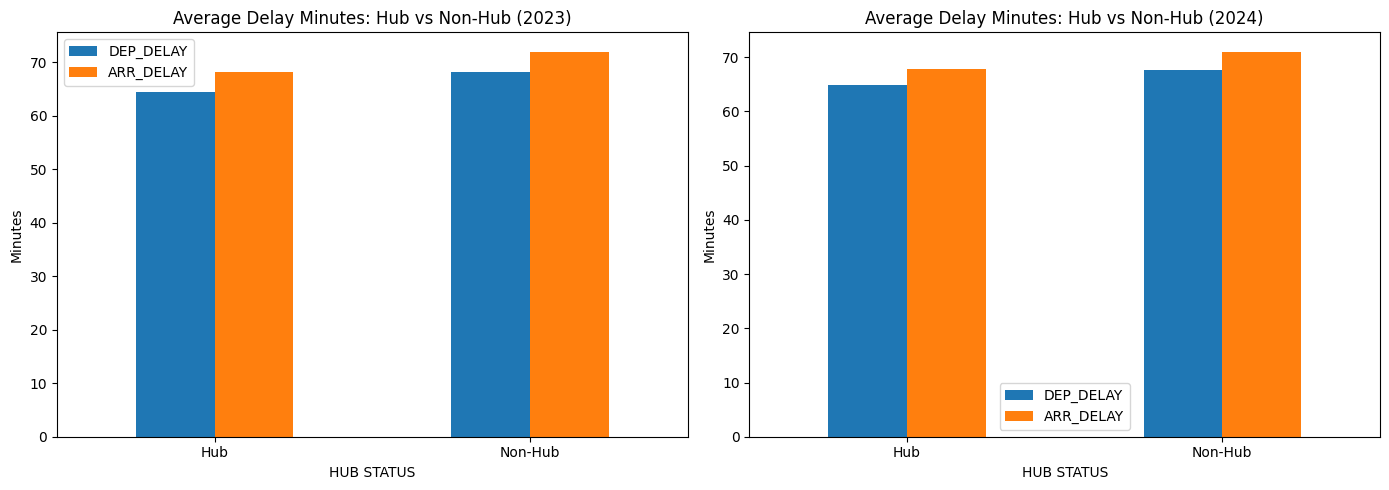

In [23]:
delay_causes = [
    "WEATHER_DELAY",
    "NAS_DELAY",
    "CARRIER_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=df_2023[delay_causes].mean().values, y=delay_causes, ax=axes[0])
axes[0].set_title("Average Delay Minutes by Cause (2023)")
axes[0].set_xlabel("Average Delay Minutes")
axes[0].set_ylabel("Delay Cause")

sns.barplot(x=df_2024[delay_causes].mean().values, y=delay_causes, ax=axes[1])
axes[1].set_title("Average Delay Minutes by Cause (2024)")
axes[1].set_xlabel("Average Delay Minutes")
axes[1].set_ylabel("Delay Cause")

plt.tight_layout()
plt.show()

top_airports_2023 = (
    df_2023.groupby("ORIGIN")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_airports_2024 = (
    df_2024.groupby("ORIGIN")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_airports_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 Departure Airports with Delays/Cancellations (2023)")
axes[0].set_xlabel("Departure Airport")
axes[0].set_ylabel("Number of Disrupted Flights")
axes[0].tick_params(axis="x", rotation=0)

top_airports_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top 10 Departure Airports with Delays/Cancellations (2024)")
axes[1].set_xlabel("Departure Airport")
axes[1].set_ylabel("Number of Disrupted Flights")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

monthly_disruptions_2023 = df_2023.groupby("MONTH").size().sort_index()
monthly_disruptions_2024 = df_2024.groupby("MONTH").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_disruptions_2023.plot(marker="o", ax=axes[0])
axes[0].set_title("Seasonal Pattern of Disruptions (2023)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Disrupted Flights")
axes[0].grid(True)

monthly_disruptions_2024.plot(marker="o", ax=axes[1])
axes[1].set_title("Seasonal Pattern of Disruptions (2024)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Disrupted Flights")
axes[1].grid(True)

plt.tight_layout()
plt.show()

dow_disruptions_2023 = df_2023.groupby("DAY_OF_WEEK").size().sort_index()
dow_disruptions_2024 = df_2024.groupby("DAY_OF_WEEK").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dow_disruptions_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("Disruptions by Day of Week (2023)")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Disrupted Flights")
axes[0].tick_params(axis="x", rotation=0)

dow_disruptions_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("Disruptions by Day of Week (2024)")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Disrupted Flights")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

hub_airports_2023 = top_airports_2023.index.tolist()
hub_airports_2024 = top_airports_2024.index.tolist()

df_2023["HUB STATUS"] = df_2023["ORIGIN"].apply(lambda x: "Hub" if x in hub_airports_2023 else "Non-Hub")
df_2024["HUB STATUS"] = df_2024["ORIGIN"].apply(lambda x: "Hub" if x in hub_airports_2024 else "Non-Hub")

hub_counts_2023 = df_2023["HUB STATUS"].value_counts()
hub_counts_2024 = df_2024["HUB STATUS"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hub_counts_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("Hub vs Non-Hub Disruptions (2023)")
axes[0].set_xlabel("Airport Type")
axes[0].set_ylabel("Number of Disrupted Flights")
axes[0].tick_params(axis="x", rotation=0)

hub_counts_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("Hub vs Non-Hub Disruptions (2024)")
axes[1].set_xlabel("Airport Type")
axes[1].set_ylabel("Number of Disrupted Flights")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

hub_delay_stats_2023 = df_2023.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]].mean()
hub_delay_stats_2024 = df_2024.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hub_delay_stats_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Delay Minutes: Hub vs Non-Hub (2023)")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis="x", rotation=0)

hub_delay_stats_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Delay Minutes: Hub vs Non-Hub (2024)")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

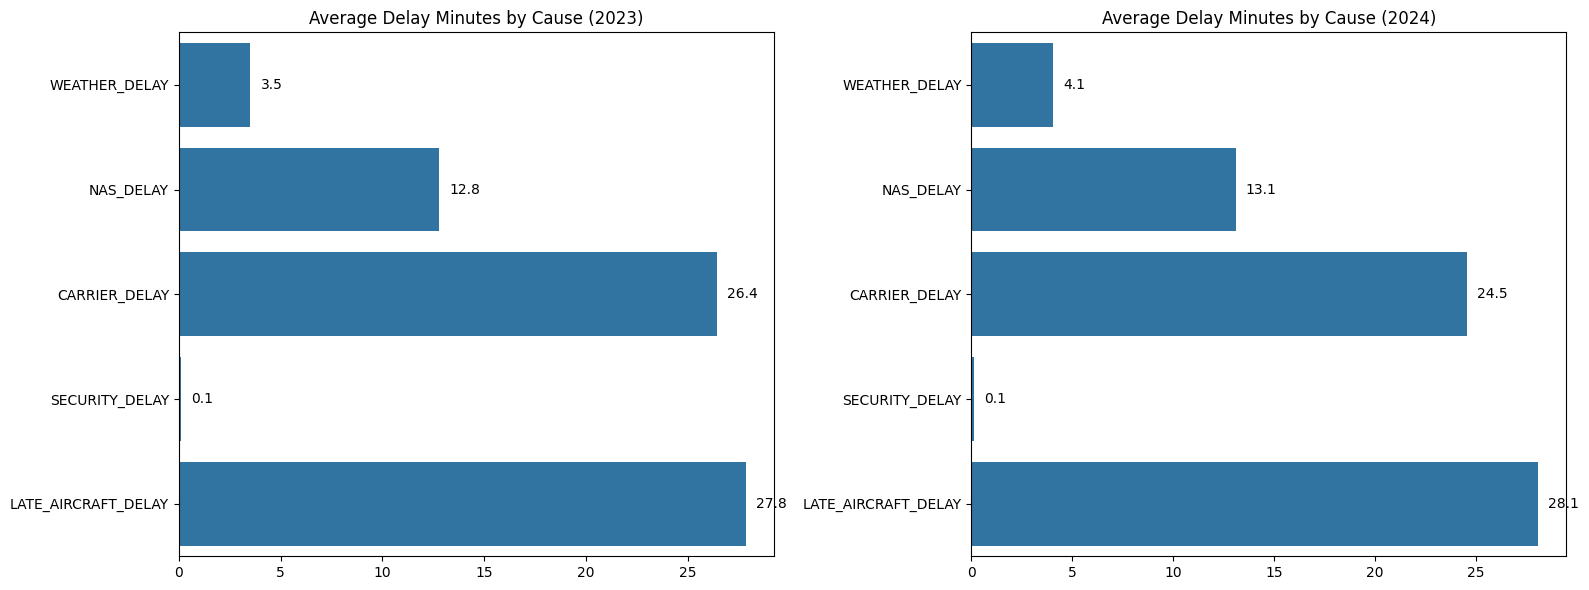

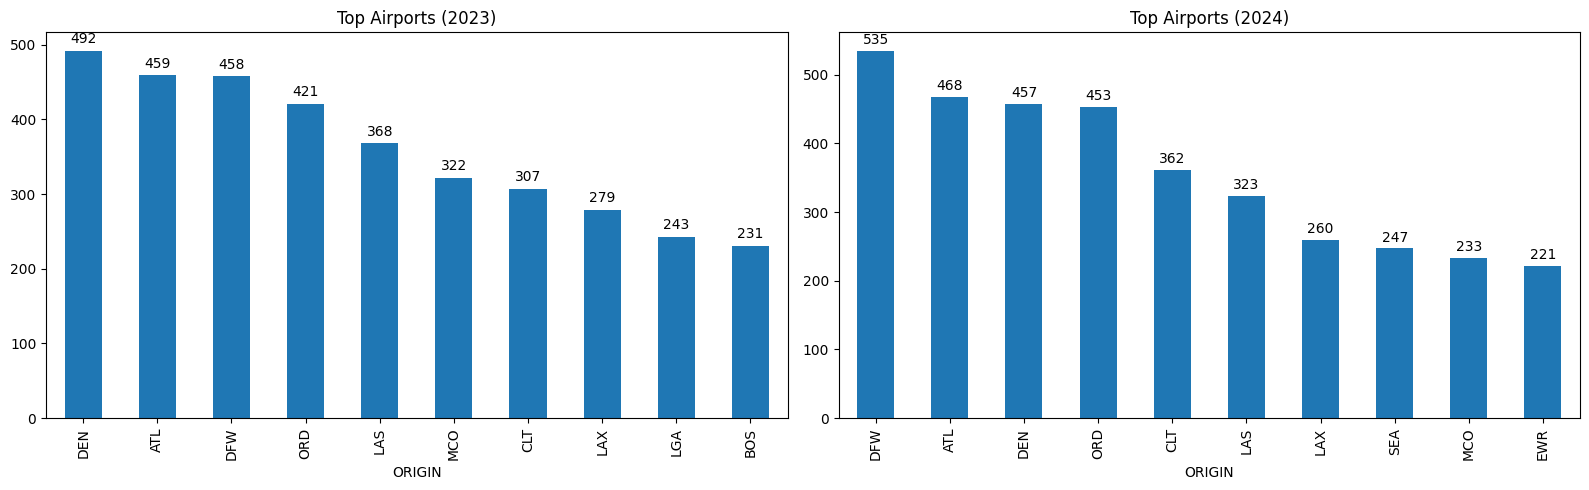

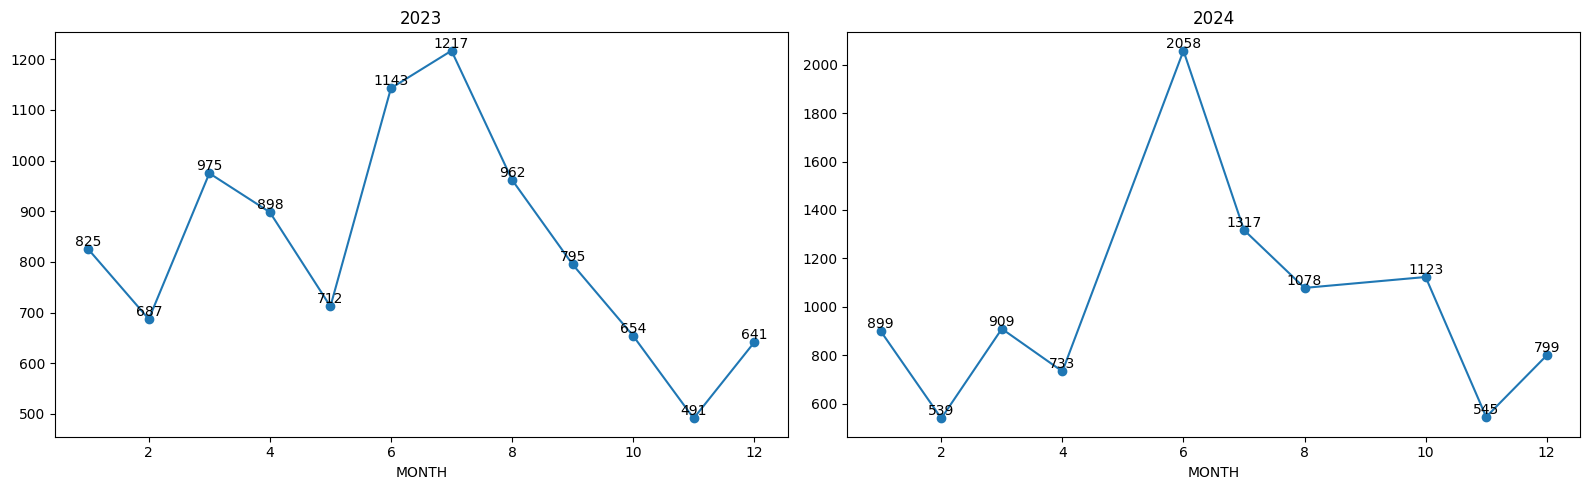

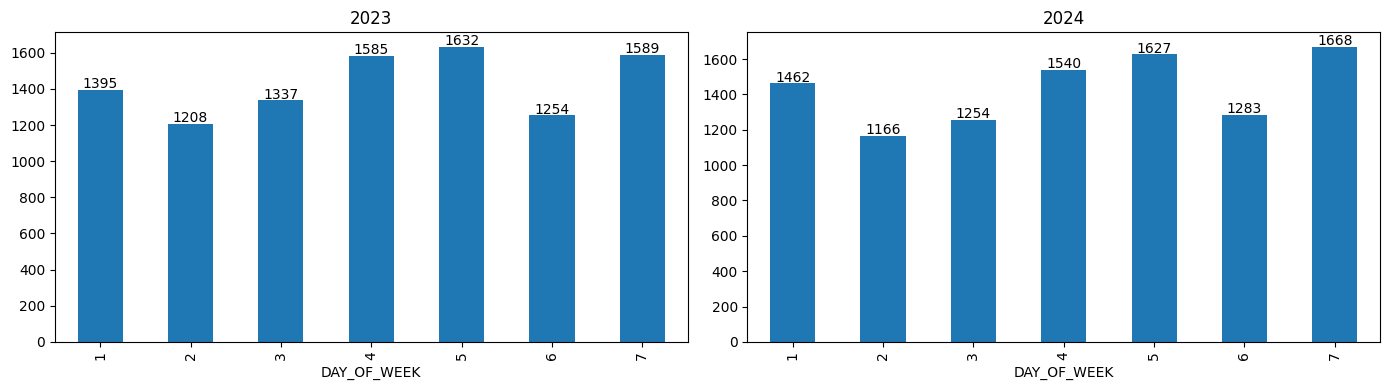

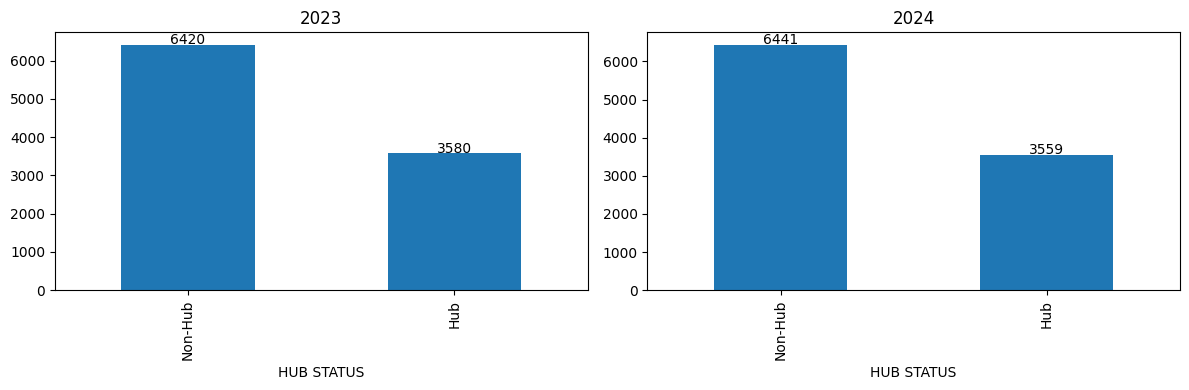

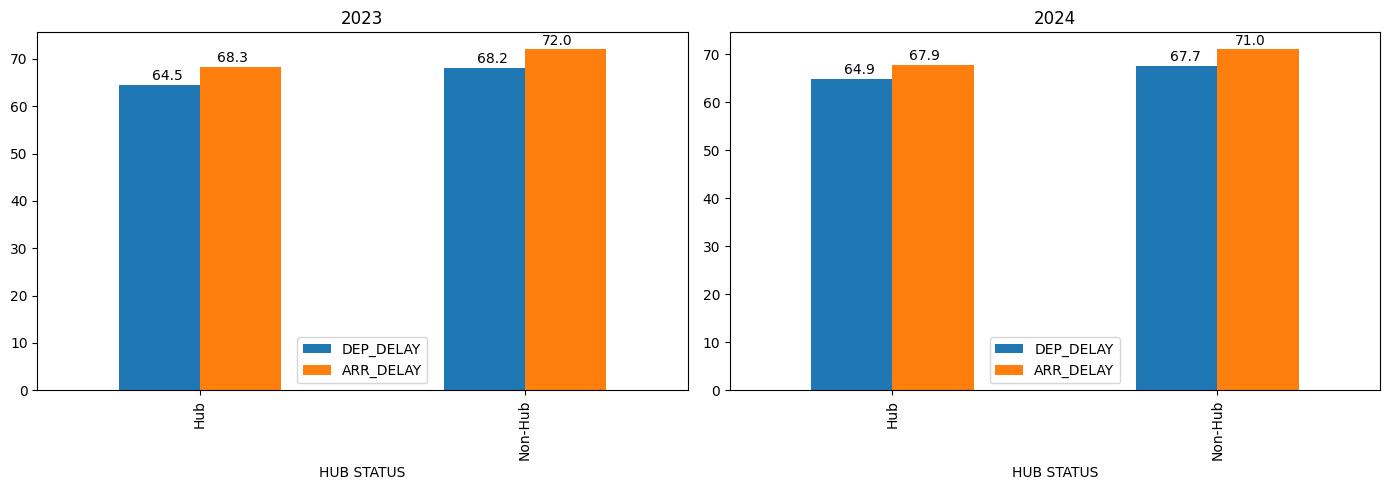

In [24]:
delay_causes = [
    "WEATHER_DELAY",
    "NAS_DELAY",
    "CARRIER_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vals_2023 = df_2023[delay_causes].mean().values
vals_2024 = df_2024[delay_causes].mean().values

sns.barplot(x=vals_2023, y=delay_causes, ax=axes[0])
axes[0].set_title("Average Delay Minutes by Cause (2023)")
for i, v in enumerate(vals_2023):
    axes[0].text(v + 0.5, i, f"{v:.1f}", va='center')

sns.barplot(x=vals_2024, y=delay_causes, ax=axes[1])
axes[1].set_title("Average Delay Minutes by Cause (2024)")
for i, v in enumerate(vals_2024):
    axes[1].text(v + 0.5, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()


top_airports_2023 = df_2023.groupby("ORIGIN").size().sort_values(ascending=False).head(10)
top_airports_2024 = df_2024.groupby("ORIGIN").size().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_airports_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Airports (2023)")
for i, v in enumerate(top_airports_2023.values):
    axes[0].text(i, v + 10, str(v), ha='center')

top_airports_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Airports (2024)")
for i, v in enumerate(top_airports_2024.values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()


monthly_disruptions_2023 = df_2023.groupby("MONTH").size().sort_index()
monthly_disruptions_2024 = df_2024.groupby("MONTH").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_disruptions_2023.plot(marker="o", ax=axes[0])
axes[0].set_title("2023")
for x, y in monthly_disruptions_2023.items():
    axes[0].text(x, y, str(y), ha='center', va='bottom')

monthly_disruptions_2024.plot(marker="o", ax=axes[1])
axes[1].set_title("2024")
for x, y in monthly_disruptions_2024.items():
    axes[1].text(x, y, str(y), ha='center', va='bottom')

plt.tight_layout()
plt.show()


dow_disruptions_2023 = df_2023.groupby("DAY_OF_WEEK").size().sort_index()
dow_disruptions_2024 = df_2024.groupby("DAY_OF_WEEK").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dow_disruptions_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("2023")
for i, v in enumerate(dow_disruptions_2023.values):
    axes[0].text(i, v + 10, str(v), ha='center')

dow_disruptions_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("2024")
for i, v in enumerate(dow_disruptions_2024.values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()


hub_airports_2023 = top_airports_2023.index.tolist()
hub_airports_2024 = top_airports_2024.index.tolist()

df_2023["HUB STATUS"] = df_2023["ORIGIN"].apply(lambda x: "Hub" if x in hub_airports_2023 else "Non-Hub")
df_2024["HUB STATUS"] = df_2024["ORIGIN"].apply(lambda x: "Hub" if x in hub_airports_2024 else "Non-Hub")

hub_counts_2023 = df_2023["HUB STATUS"].value_counts()
hub_counts_2024 = df_2024["HUB STATUS"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hub_counts_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("2023")
for i, v in enumerate(hub_counts_2023.values):
    axes[0].text(i, v + 10, str(v), ha='center')

hub_counts_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("2024")
for i, v in enumerate(hub_counts_2024.values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()


hub_delay_stats_2023 = df_2023.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]].mean()
hub_delay_stats_2024 = df_2024.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hub_delay_stats_2023.plot(kind="bar", ax=axes[0])
axes[0].set_title("2023")
for i, row in enumerate(hub_delay_stats_2023.values):
    for j, v in enumerate(row):
        axes[0].text(i + j*0.2 - 0.1, v + 1, f"{v:.1f}", ha='center')

hub_delay_stats_2024.plot(kind="bar", ax=axes[1])
axes[1].set_title("2024")
for i, row in enumerate(hub_delay_stats_2024.values):
    for j, v in enumerate(row):
        axes[1].text(i + j*0.2 - 0.1, v + 1, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

DELAYED V NOT DELAYED
Just how many flights were delayed vs not.
DELAY CAUSES
Average minutes from different causes:
weather
air traffic (NAS)
airline issues (carrier)
security
late incoming planes
TOP AIRPORTS
Which airports have the most delays/cancellations.
MONTH
How delays change throughout the year.
WEEK
Which days are worse for delays.
HUB V NONHUB
Comparing big airports vs smaller ones:
how many disruptions
how bad the delays are
VISUALS
Side-by-side charts for 2023 vs 2024
Line graphs for trends
Numbers are shown on the charts so it’s easy to read